In [236]:
# loading libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [237]:
# loading csv file
df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [238]:
# information of the datatset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [239]:
# shape of the datatset
print(df.shape)

(50000, 2)


In [240]:
# checking for any null values
df.isna().sum()

,0
review,0
sentiment,0


In [241]:
# checking for any duplicated values
df.duplicated().sum()

np.int64(418)

In [242]:
# removing duplicate values
df.drop_duplicates(inplace=True)
print(df.shape)

(49582, 2)


In [243]:
print(df['review'][1])
print("--------------------------")
print(df['review'][42])

A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well done.
-

In [244]:
# count the values of target
print(df['sentiment'].value_counts())

sentiment
positive    24884
negative    24698
Name: count, dtype: int64


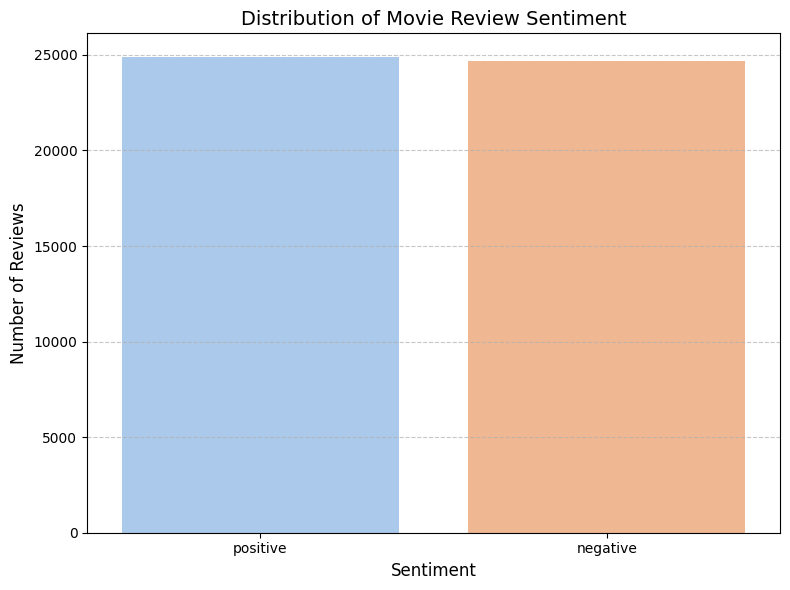

In [210]:
# visualize data distribution in sentiment
sentiment_counts = df['sentiment'].value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='pastel')
plt.title('Distribution of Movie Review Sentiment', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

We can conclude that the datatset is balanced

In [211]:
# too many rows.
# we will be using LOO in future. If we use too many rows, then it will slow the training.
# take 1000 rows and shuffle it

from sklearn.model_selection import train_test_split
_,sample_df = train_test_split(df,test_size=1000,stratify=df['sentiment'],random_state=42)

# shape of the new sample_df
print(sample_df.shape)

(1000, 2)


In [212]:
# randomly shuffule 1000 rows
sample_df = sample_df.sample(frac=1,random_state=42).reset_index(drop=True)
sample_df.head()

,review,sentiment
0,This had a great cast with big-name stars like...,negative
1,`Manna From Heaven' is a delightfully compelli...,positive
2,"Odd one should be able to stumble into ""Classe...",positive
3,This is one of the greatest love story movies ...,positive
4,"To remake ""Lost Horizon"", as a musical, the ne...",negative


In [213]:
# saving to another csv file
sample_df.to_csv("sample_imdb_datatset.csv",index=False)
print("Saved csv file!")

Saved csv file!


In [214]:
# loading new datatset - 1000 rows
new_df = pd.read_csv("sample_imdb_datatset.csv")
new_df.head()

,review,sentiment
0,This had a great cast with big-name stars like...,negative
1,`Manna From Heaven' is a delightfully compelli...,positive
2,"Odd one should be able to stumble into ""Classe...",positive
3,This is one of the greatest love story movies ...,positive
4,"To remake ""Lost Horizon"", as a musical, the ne...",negative


In [215]:
print(new_df.shape)

(1000, 2)


In [216]:
# encoding the target
target_dict = {"positive":1,"negative":0}
new_df['sentiment'] = new_df['sentiment'].map(target_dict)
print(new_df['sentiment'].head())

0    0
1    1
2    1
3    1
4    0
Name: sentiment, dtype: int64


In [217]:
# cleaning the text
import re

def clean_text(text):
  text = re.sub(r'<br\s*/?>', ' ', text)      # remove HTML line breaks
  text = re.sub(r'<.*?>', ' ', text)           # remove any other HTML tags
  text = re.sub(r'http\S+|www\S+', ' ', text)  # remove URLs
  text = re.sub(r'\s+', ' ', text).strip()     # collapse whitespace
  return text

In [218]:
# applying the clean_text function
new_df['cleaned_review'] = new_df['review'].apply(clean_text)
new_df.head()

,review,sentiment,cleaned_review
0,This had a great cast with big-name stars like...,0,This had a great cast with big-name stars like...
1,`Manna From Heaven' is a delightfully compelli...,1,`Manna From Heaven' is a delightfully compelli...
2,"Odd one should be able to stumble into ""Classe...",1,"Odd one should be able to stumble into ""Classe..."
3,This is one of the greatest love story movies ...,1,This is one of the greatest love story movies ...
4,"To remake ""Lost Horizon"", as a musical, the ne...",0,"To remake ""Lost Horizon"", as a musical, the ne..."


In [219]:
print(new_df['cleaned_review'][1])

`Manna From Heaven' is a delightfully compelling film. Within the shifting paradox of values in middle-class Americans from 40 years ago to the present day, the plot tweaks the concerns and hopes of an interesting range of `Damon Runyonesque' characters. Their struggles with moral dilemmas, dotting on `what might have been,' hopes to yet fulfill youthful dreams, romantic yearnings, and `hit it big' combine to make a most entertaining film. Rather than relying upon `in-your- face' sexual explicitness, the burgeoning relationship between Inez and Mac/Bake is classically subtle but clear. His untying the knot in her shoelace at the Art Gallery and their heat in their poker game is outstanding The script's crisp writing is skillfully interpreted by an outstanding star and supporting cast. One of the few films I have ever fone to see twice in its opening run, `Manna From Heaven' definitely warrants national distribution. Conrad F. Toepfer


In [220]:
!pip install -q sentence-transformers

In [221]:
# generate sentence embeddings
from sentence_transformers import SentenceTransformer

# loading a pre-trained sentence transformer model
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

sentences = new_df['cleaned_review'].tolist()
embeddings = model.encode(sentences, show_progress_bar=True,batch_size=32)

# shape of the embeddings
print(embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

(1000, 384)


In [222]:
# columns of new_df
print(new_df.columns)

Index(['review', 'sentiment', 'cleaned_review'], dtype='object')


In [223]:
# save embeddings + labels
np.save("embeddings.npy",embeddings)
new_df[['sentiment']].to_csv('sentiments.csv',index=False)
print("Saved embeddings and labels (sentiments)")

Saved embeddings and labels (sentiments)


In [224]:
# now loading embedding and labels
embeddings = np.load("embeddings.npy")
labels = pd.read_csv('sentiments.csv')['sentiment'].values

In [225]:
# shape of embeddings
print(embeddings.shape)

(1000, 384)


In [226]:
# shape of labels datatset
print(labels.shape)

(1000,)


In [227]:
# now using train_test_split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test,idx_train,idx_test = train_test_split(embeddings,labels,np.arange(len(labels)),test_size=0.2,stratify=labels,random_state=42)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (800, 384)  Test: (200, 384)


In [228]:
# loading Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [229]:
# finding accuracy score
y_pred = lr.predict(X_test)
acc = accuracy_score(y_test,y_pred)
print(f"Baseline test accuracy: {acc:.4f}")

Baseline test accuracy: 0.8000


In [230]:
# finding log loss
probs = lr.predict_proba(X_test)[:,1]
loss = log_loss(y_test,probs)
print(f"baseline log loss: {loss:.4f}")

baseline log loss: 0.4594


In [231]:
# Using LOO -->(Leave One Out)
from tqdm import tqdm

n_train = X_train.shape[0]
influences = np.zeros(n_train)
baseline_loss = loss  # 0.4594, from earlier cell

for i in tqdm(range(n_train)):
    X_loo = np.delete(X_train, i, axis=0)
    y_loo = np.delete(y_train, i, axis=0)

    model_loo = LogisticRegression(max_iter=1000)   # fresh model each time
    model_loo.fit(X_loo, y_loo)

    probs_loo = model_loo.predict_proba(X_test)[:, 1]
    loss_loo = log_loss(y_test, probs_loo)

    influences[i] = loss_loo - baseline_loss

100%|██████████| 800/800 [00:14<00:00, 56.96it/s]


In [232]:
# attach influence scores back to the original reviews
loo_results = pd.DataFrame({
    'train_idx': idx_train,
    'influence': influences,
})

loo_results['review'] = new_df.loc[loo_results['train_idx'], 'cleaned_review'].values
loo_results['sentiment'] = new_df.loc[loo_results['train_idx'], 'sentiment'].values

loo_results = loo_results.sort_values('influence', ascending=False).reset_index(drop=True)
loo_results.to_csv('loo_results.csv', index=False)

print("Saved loo_results.csv")
loo_results.head()

Saved loo_results.csv


,train_idx,influence,review,sentiment
0,532,0.001282,it's movies like these that make you wish that...,1
1,746,0.001148,This movie was recently shown subtitled not du...,1
2,363,0.001053,Watching David&Bathsheba is a much better way ...,1
3,496,0.001016,An in-name-only sequel to John Carpenter's Vam...,0
4,777,0.001002,The opening scene makes you feel like you're w...,0


In [233]:
# most HELPFUL points (removing them hurt performance the most)
print("=== Top 10 most HELPFUL training points ===")
for _, row in loo_results.head(10).iterrows():
    print(f"[{row['sentiment']}] influence={row['influence']:.5f}")
    print(row['review'][:200], "\n")

=== Top 10 most HELPFUL training points ===
[1] influence=0.00128
it's movies like these that make you wish that you never picked on the nerd growing up in school. If you liked this movie, then I would suggest you watch Valentine. I just found out today that the guy 

[1] influence=0.00115
This movie was recently shown subtitled not dubbed, on Australia's Special Broadcasting Service. I thought I read here that there is sometimes an assumption that *Revenge of the Rats* is a sequel. In  

[1] influence=0.00105
Watching David&Bathsheba is a much better way of getting your bible lesson that going to Sunday school. Despite a script that at times is unintentionally funny the film is highly entertaining. The stu 

[0] influence=0.00102
An in-name-only sequel to John Carpenter's Vampires, this movie takes place in Thailand and involves a sect of bad vampires, who enjoy killing people, and a sect of good vampires who do not. While it' 

[0] influence=0.00100
The opening scene makes you feel l

In [234]:
# most HARMFUL points (removing them helped performance the most)
print("=== Top 10 most HARMFUL training points ===")
for _, row in loo_results.tail(10).iterrows():
    print(f"[{row['sentiment']}] influence={row['influence']:.5f}")
    print(row['review'][:200], "\n")

=== Top 10 most HARMFUL training points ===
[0] influence=-0.00103
This documentary is at its best when it is simply showing the ayurvedic healers' offices and treatment preparation. There is no denying the grinding poverty in India and desperation of even their weal 

[1] influence=-0.00106
I could not agree less with the rating that was given to this movie, and I believe this is a sample of how short minded most of spectators are all over the world. Really... Are you forgetting that Cin 

[0] influence=-0.00108
My title above says it all. Let me make it clearer. If you have seen the BBC's "Planet Earth" , which I am sure most of you have , then you are not gonna like this movie too much. And I own all the di 

[0] influence=-0.00109
I don't know about you, but what I love about Tom and Jerry cartoons is the (often violent) interaction between the two characters. Mouse In Manhattan sees Jerry leaving Tom behind to have an adventur 

[1] influence=-0.00109
Wizards of the Lost Kingdom i

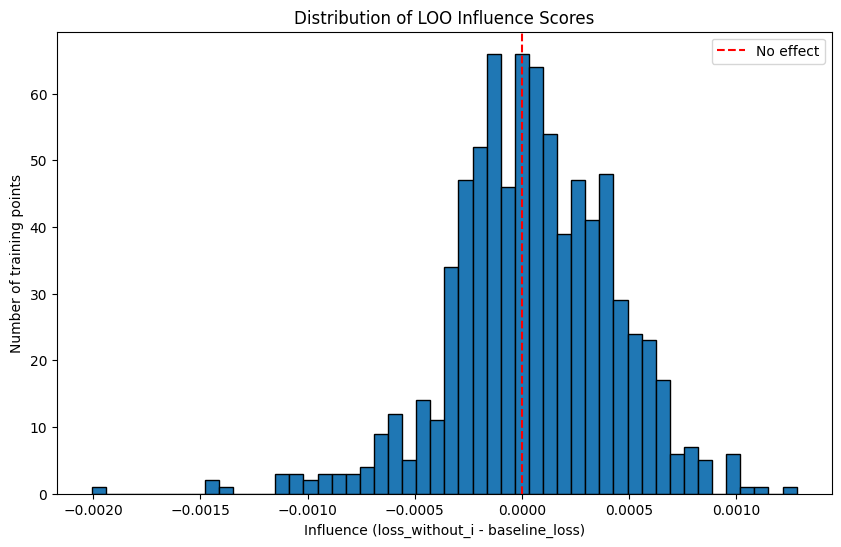

In [235]:
# visualizing the influence distribution
plt.figure(figsize=(10, 6))
plt.hist(loo_results['influence'], bins=50, edgecolor='black')
plt.axvline(0, color='red', linestyle='--', label='No effect')
plt.xlabel('Influence (loss_without_i - baseline_loss)')
plt.ylabel('Number of training points')
plt.title('Distribution of LOO Influence Scores')
plt.legend()
plt.show()